# Resolving the G1-S artifact

Adding a +1 offset to the genome deconvolution handles the initial issue of small counts near zero creating a spike in the smoothing transition from G1 to S/G2M. There still appears to be an elevated occupancy in G1 across the entire genome that isn't fully understood.



In [7]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1689]:
chrom = 16
span = 771000, 771600


In [1690]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, span, log=False)


Adding a deconvolution offset to G: 1


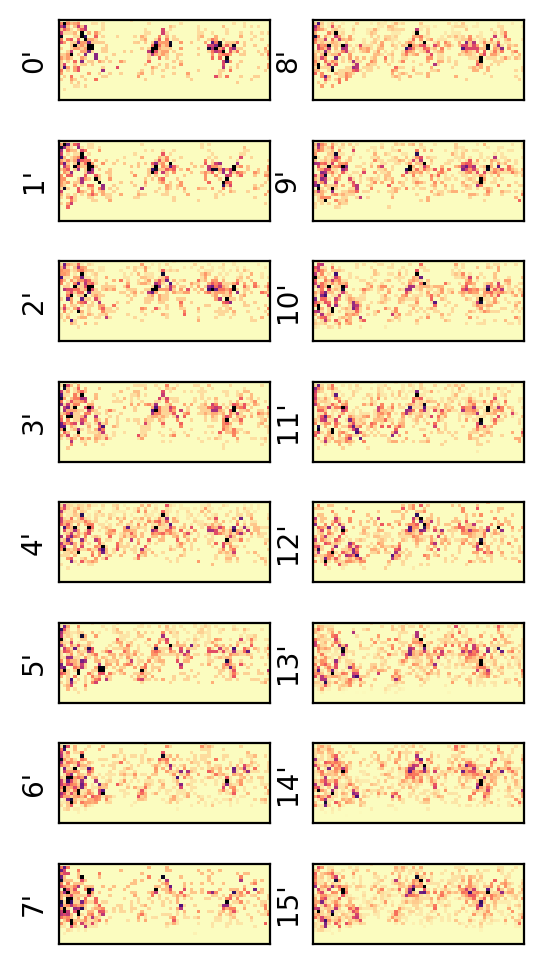

In [1726]:
from src.mnase_total_curve_debugging import plot_G_img_data

G1_img_data = genome_deconvolution.combined_model.chrom1_model.deconv_hist_unflattened
plot_G_img_data(G1_img_data)

In [1749]:
genome_deconvolution.combined_model.deconvolve(gamma=0.06, padding_type='left')

Adding a deconvolution offset to G: 1
Deconvolving combined model with gamma=0.06
Deconvolving bin size: 10x10
of G shape: (31, 1560)
Deconvolving with gamma=0.06
0/1560 - 00:00:00.314
500/1560 - 00:02:22.990
1000/1560 - 00:04:44.025
1500/1560 - 00:07:08.056
Deconvolved in : 00:07:25.396
The fitting norm is 1.50, the smoothing norm is: 4.19


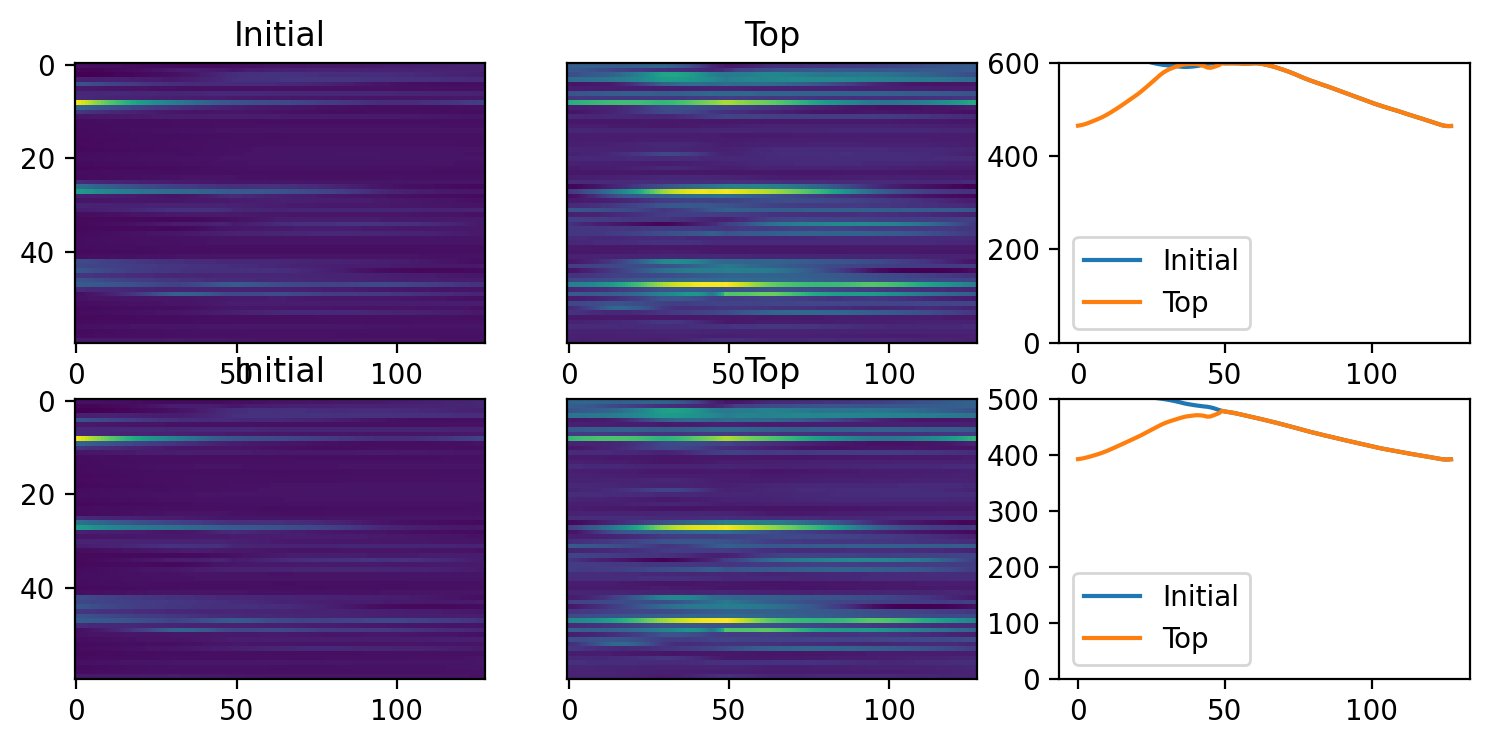

In [1750]:
from src.mnase_total_curve_debugging import plot_f_genome_deconvolution_nuc_reads

plot_f_genome_deconvolution_nuc_reads(genome_deconvolution)

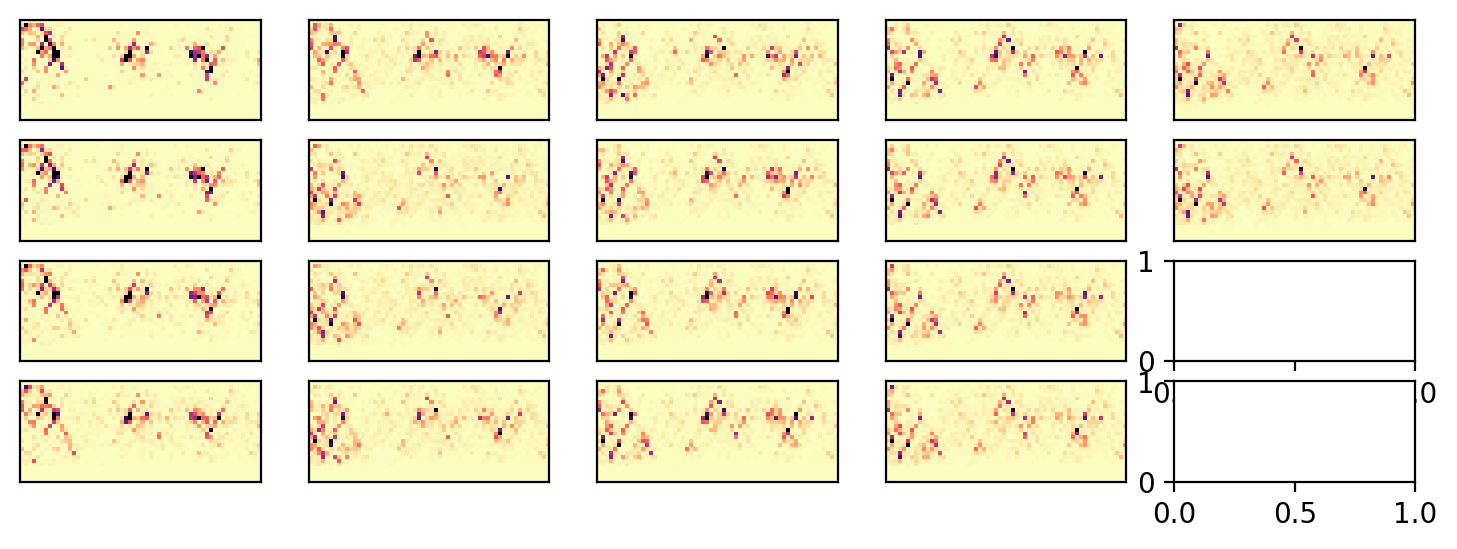

In [1866]:

img_shape = genome_deconvolution.combined_model\
    .chrom1_model.deconv_hist_unflattened.shape[1:]
f_imgs = genome_deconvolution.combined_model.deconvolved_f_value.reshape(
    (-1, *img_shape))
    
def plot_f_imgs(f_imgs):
    index = 0
    fig, axs = plt.subplots(4, 5, figsize=(9, 3))
    axs = np.array(axs).T.flatten()

    for i in range(0, 178, 10):
        ax = axs[index]
        f_img = f_imgs[i]
        normalized_f_img = f_img / f_img.sum() * 2000
        ax.imshow(normalized_f_img, origin='lower', vmin=1, vmax=5, 
                   aspect='auto', cmap='magma_r')
        ax.set_xticks([])
        ax.set_yticks([])
        index += 1

plot_f_imgs(f_imgs)

In [1752]:
# Let's summarize:
# 1. Normalize the total read counts on analysis
# 2. Padding both sides creates an interesting curve, the initial to postG
#

In [1892]:

def plot_f_img(ax, f_img):
    normalized_f_img = f_img / f_img.sum() * f_img.shape[0]*f_img.shape[1]        
    ax.imshow(normalized_f_img, origin='lower', vmin=1, vmax=5, 
               aspect='auto', cmap='magma_r')
    ax.set_xticks([])
    ax.set_yticks([])

def plot_f_imgs_wide(f_imgs):
    index = 0
    fig, axs = plt.subplots(8, 1, figsize=(19, 9))
    axs = np.array(axs).T.flatten()

    rg1_indices = config.get_Hpositions_for_phase('RG1')
    cg1_indices = config.get_Hpositions_for_phase('CG1')
    s_indices = config.get_Hpositions_for_phase('S')
    pg1_indices = config.get_Hpositions_for_phase('postG1')
    
    indices = [
        rg1_indices[2], rg1_indices[-2],
        cg1_indices[2], cg1_indices[-2],
        s_indices[2], s_indices[-2],
        pg1_indices[2], pg1_indices[-2],
    ]
    for i in indices:
        ax = axs[index]
        f_img = f_imgs[int(i)]
        plot_f_img(ax, f_img)
        index += 1

def plot_f_imgs_loaded(load_path):
    f_imgs = np.load(load_path)
    plot_f_imgs_wide(f_imgs)


In [1796]:
def plot(load_path):
    test_f = np.load(load_path)
    plt.plot(test_f[t_indices].mean(axis=1).mean(axis=1), label='top', c='red')
    plt.plot(test_f[i_indices].mean(axis=1).mean(axis=1), label='initial', c='blue')
    plt.legend()

In [1841]:
def plot_set(gamma, padding_type):
    plt.figure(figsize=(9, 2))
    plt.subplot(1, 3, 1)
#     plot(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr10/chr10_194000_204000.npy')
#     plt.title("Early")
#     plt.subplot(1, 3, 2)
#     plot(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr3/chr3_260000_270000.npy')
#     plt.title("Late")
#     plt.subplot(1, 3, 3)
    plot(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr16/chr16_770000_780000.npy')
    plt.title("CLB2")
    plt.suptitle(f"Gamma={gamma}, padding={padding_type}")
    plt.subplots_adjust(top=0.75)

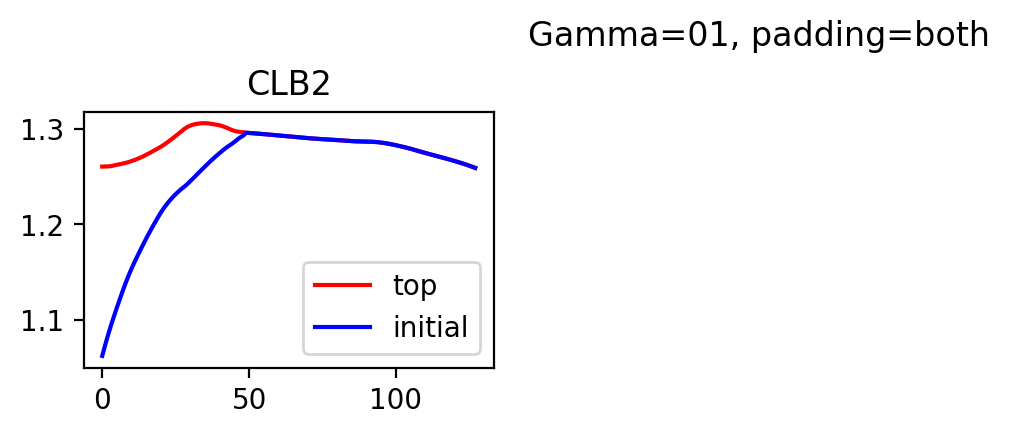

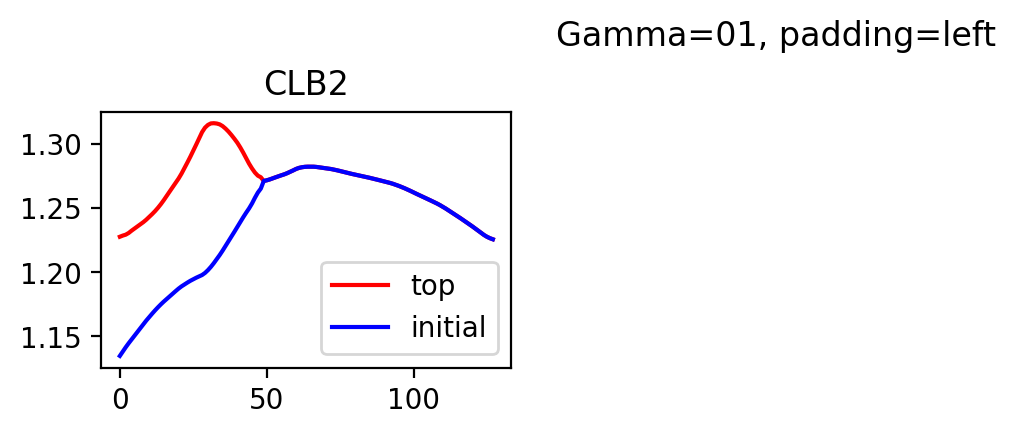

In [1842]:
plot_set('01', 'both')
plot_set('01', 'left')

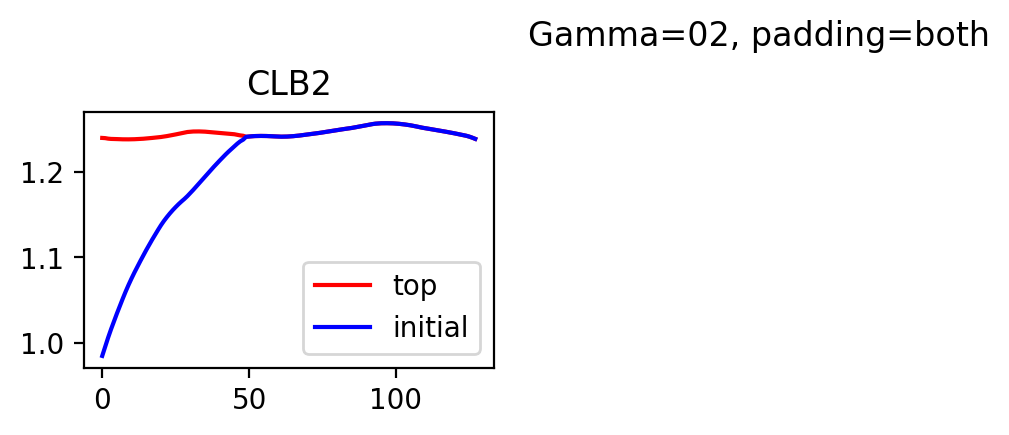

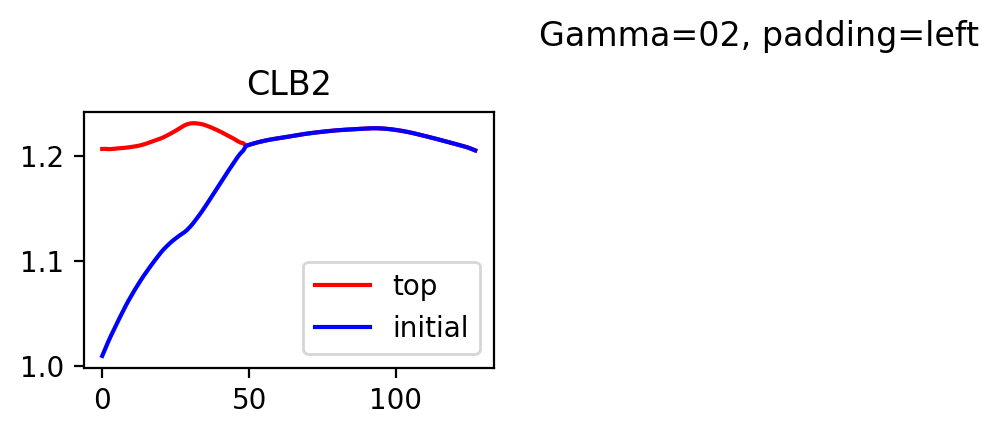

In [1843]:
plot_set('02', 'both')
plot_set('02', 'left')

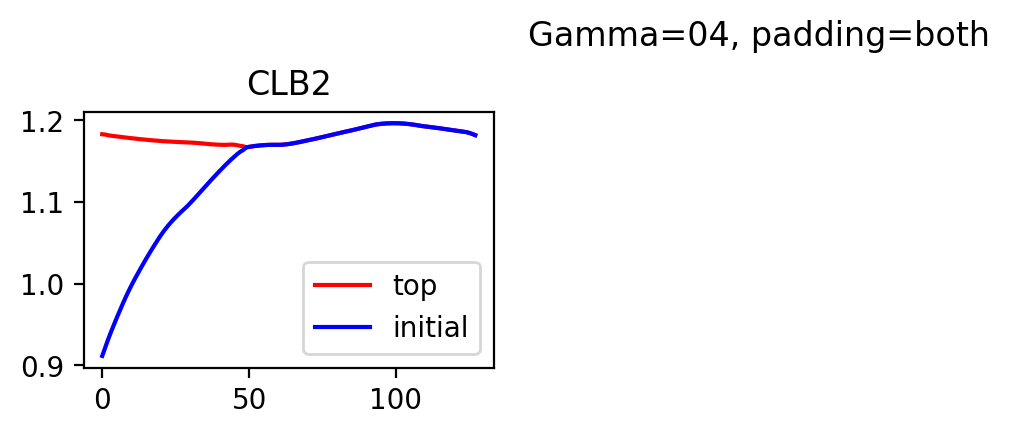

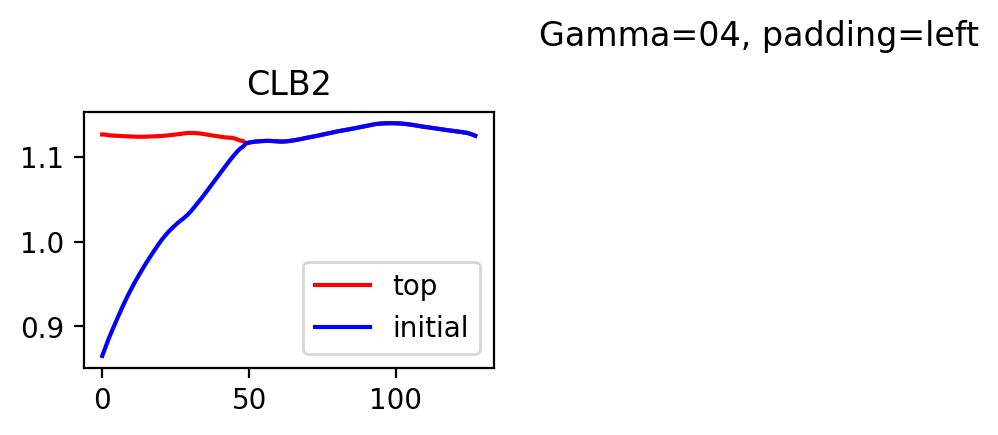

In [1844]:
plot_set('04', 'both')
plot_set('04', 'left')

In [1848]:

def plot_f_imgs_loaded(load_path):
    f_imgs = np.load(load_path)
    plot_f_imgs_wide(f_imgs)

load_path = (f'output/deconvolved_test_windows_g{gamma}_'
             f'{padding_type}/data/chr10/chr10_194000_204000.npy')

def plot_f_imgs_set(gamma, padding_type):
    #plot_f_imgs_loaded(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr10/chr10_194000_204000.npy')
    #plt.suptitle(f"Early, gamma={gamma}, padding_type={padding_type}")
    #plot_f_imgs_loaded(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr3/chr3_260000_270000.npy')
    #plt.suptitle(f"Late, gamma={gamma}, padding_type={padding_type}")
    plot_f_imgs_loaded(f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr16/chr16_770000_780000.npy')
    plt.suptitle(f"CLB2, gamma={gamma}, padding_type={padding_type}")


In [2084]:
gamma = '01'
padding_type = 'both'

filepath = f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr16/chr16_770000_780000.npy'
f_imgs = np.load(filepath)

for i in range(f_imgs.shape[0]):
    plt.figure(figsize=(19, 1.5))
    ax = plt.gca()
    f_img = f_imgs[i]
    plot_f_img(ax, f_img)
    plt.title(f"{i+1}/{f_imgs.shape[0]}", pad=9)
    plt.subplots_adjust(top=0.78)
    plt.savefig(f'output/tmp/f_{i}.png')
    plt.close()


In [2088]:
from src.mnase_total_curve_debugging import create_animation

create_animation(t_indices, 'output/tmp/animated_t.gif')


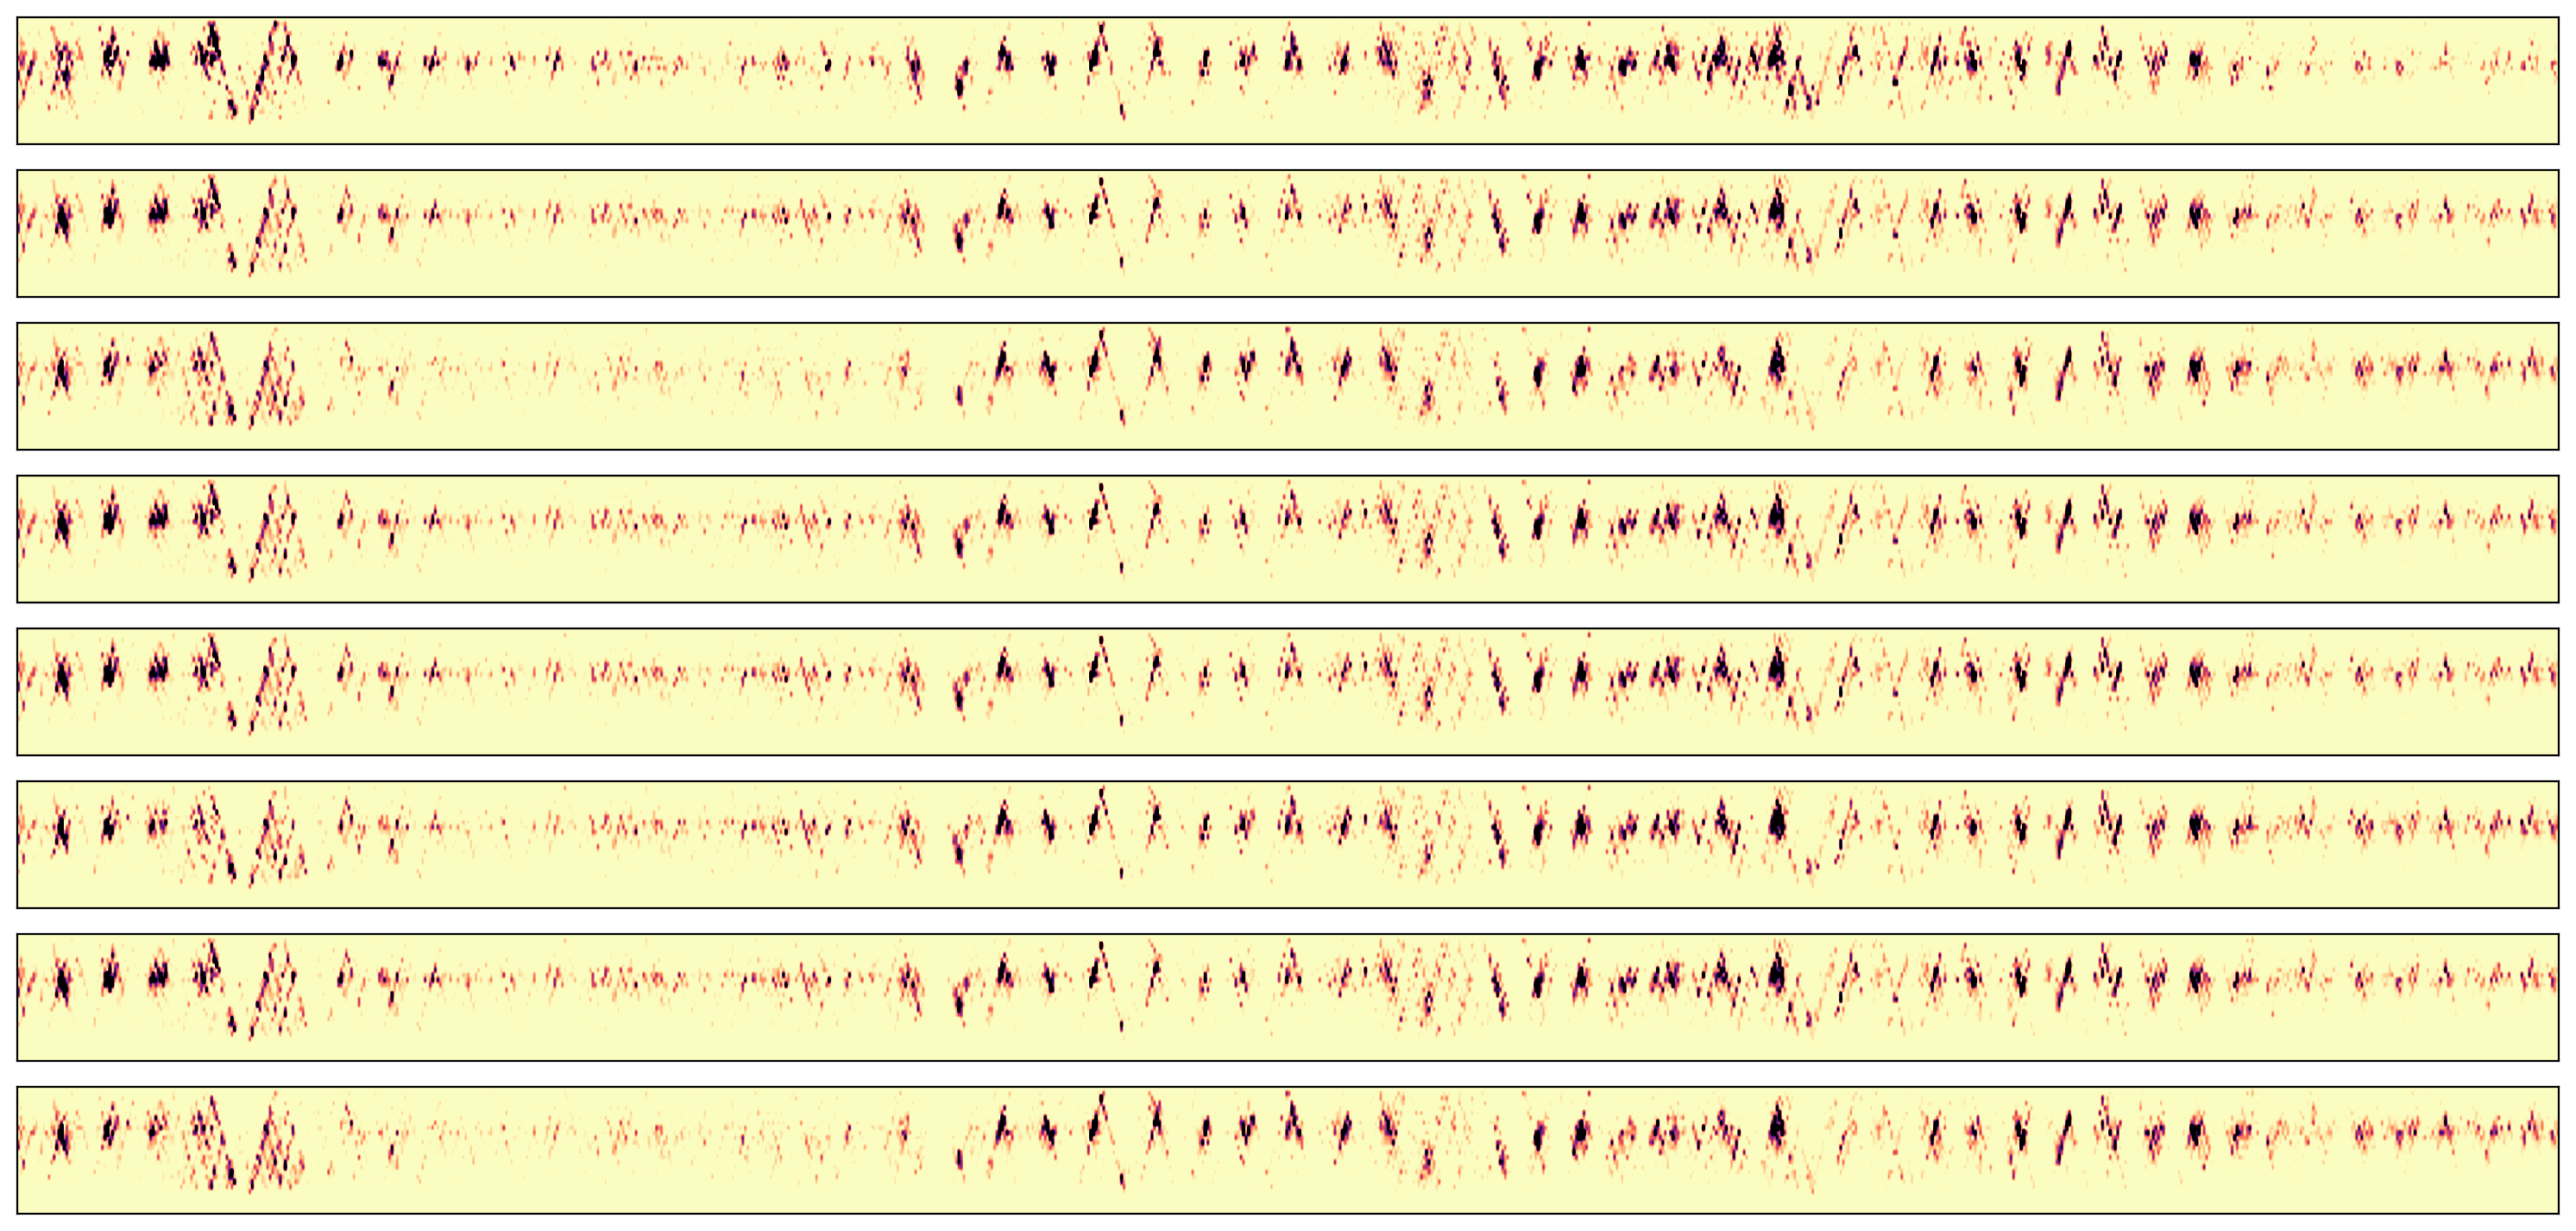

In [2089]:
plot_f_imgs_loaded(filepath)

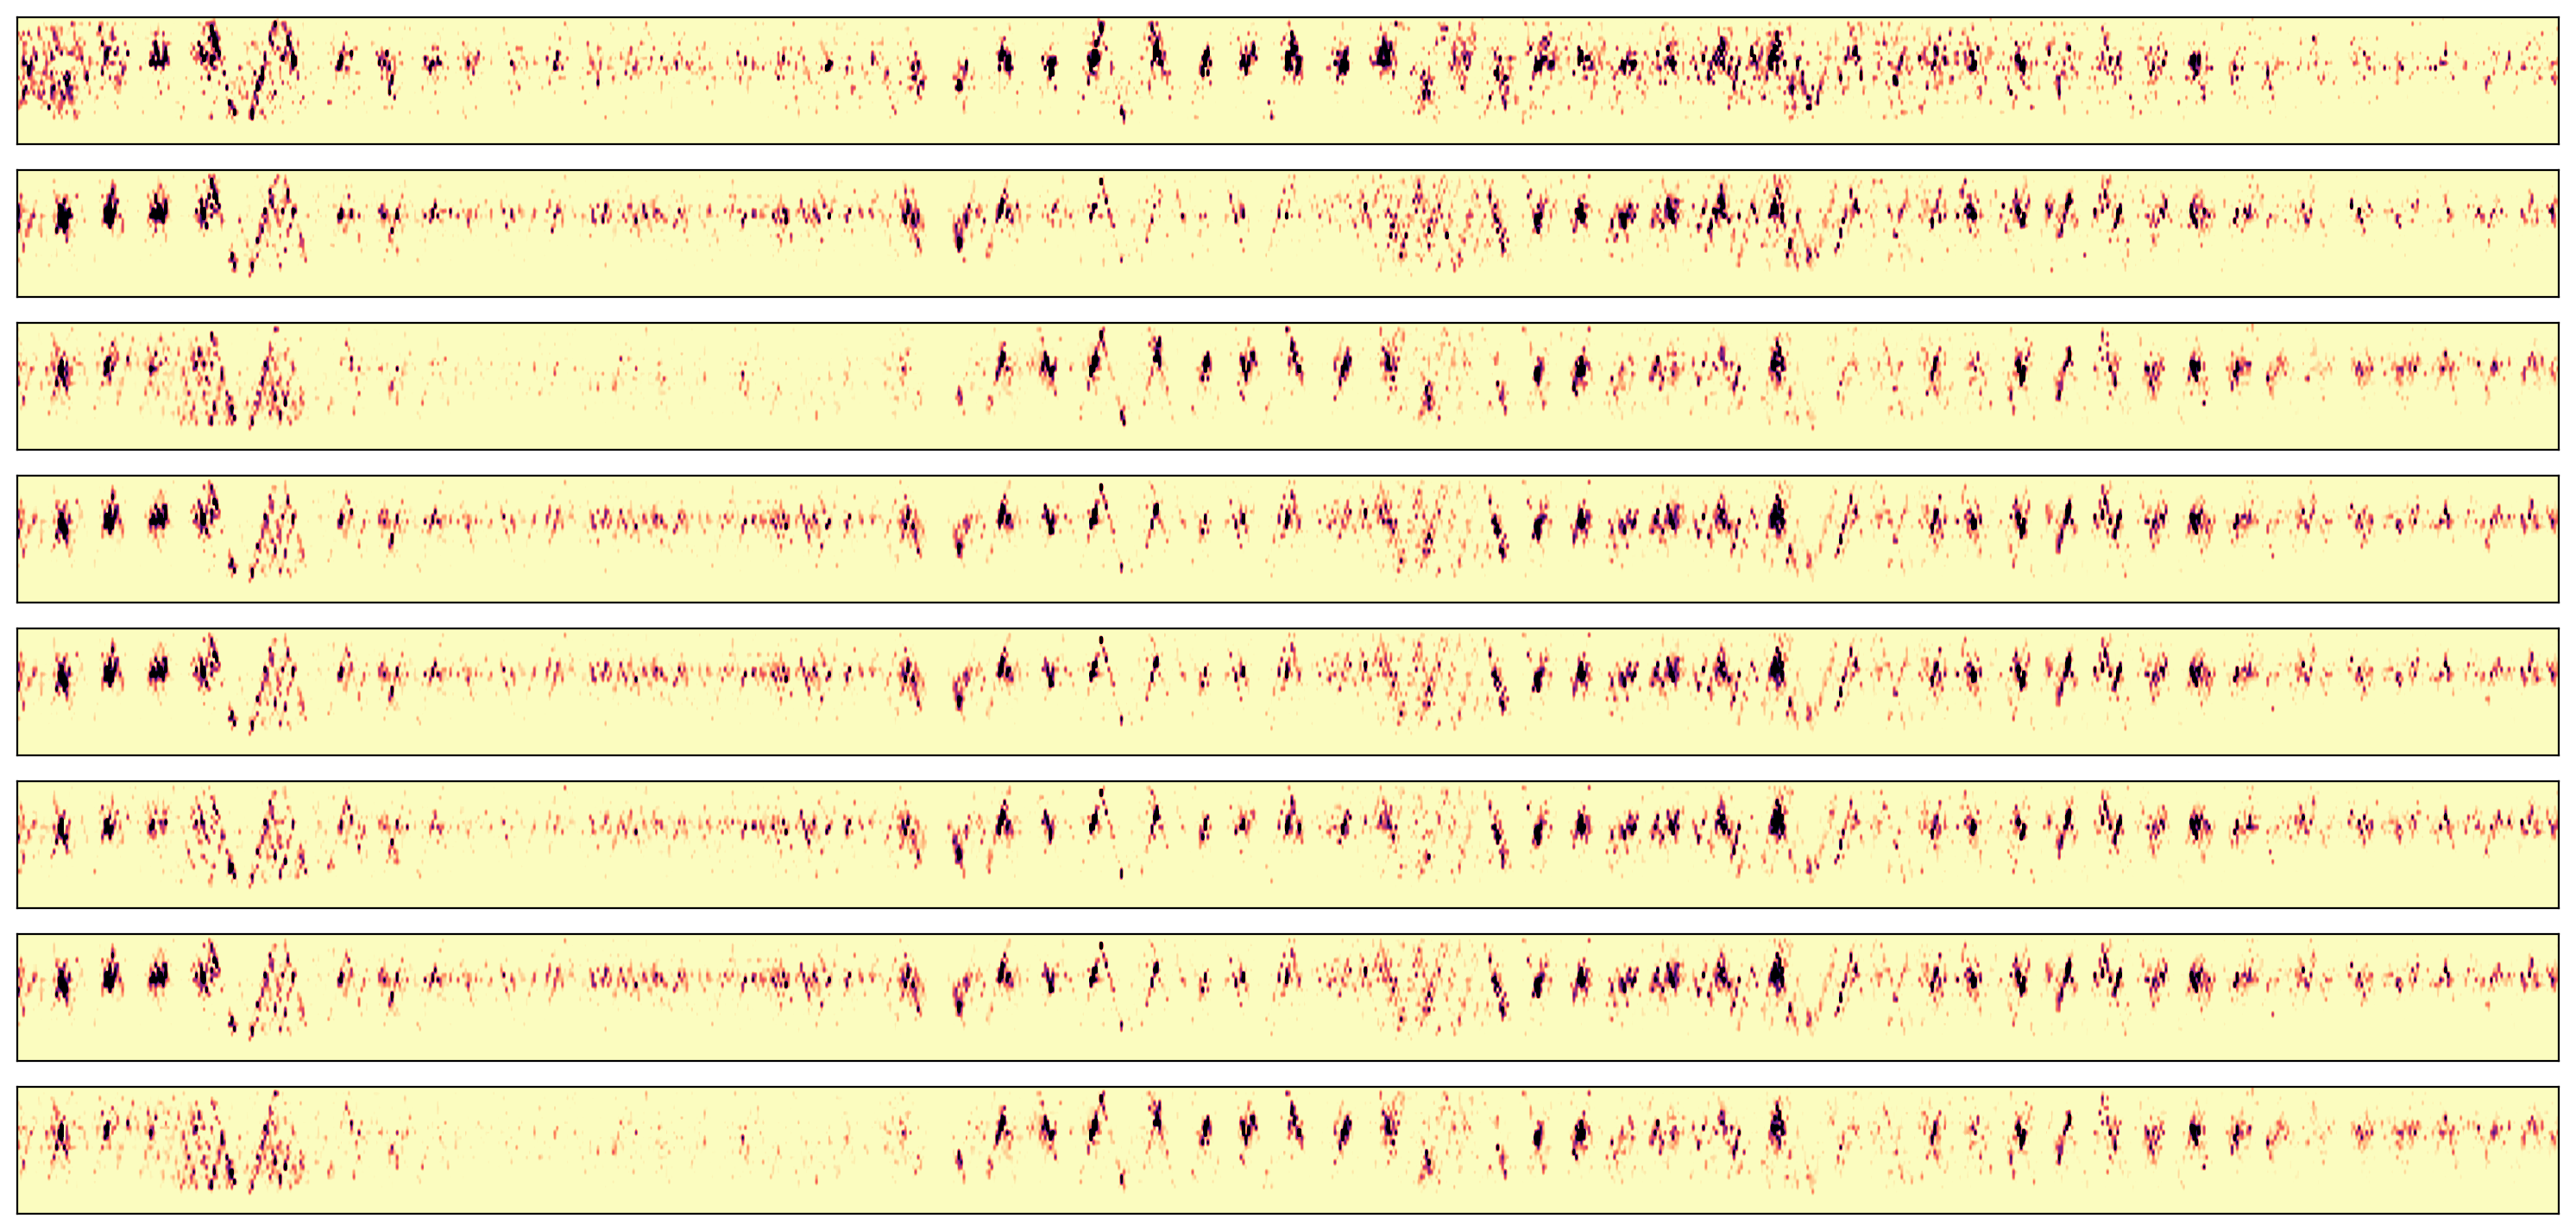

In [1899]:
plot_f_imgs_loaded(f'output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/data/chr16/chr16_770000_780000.npy')

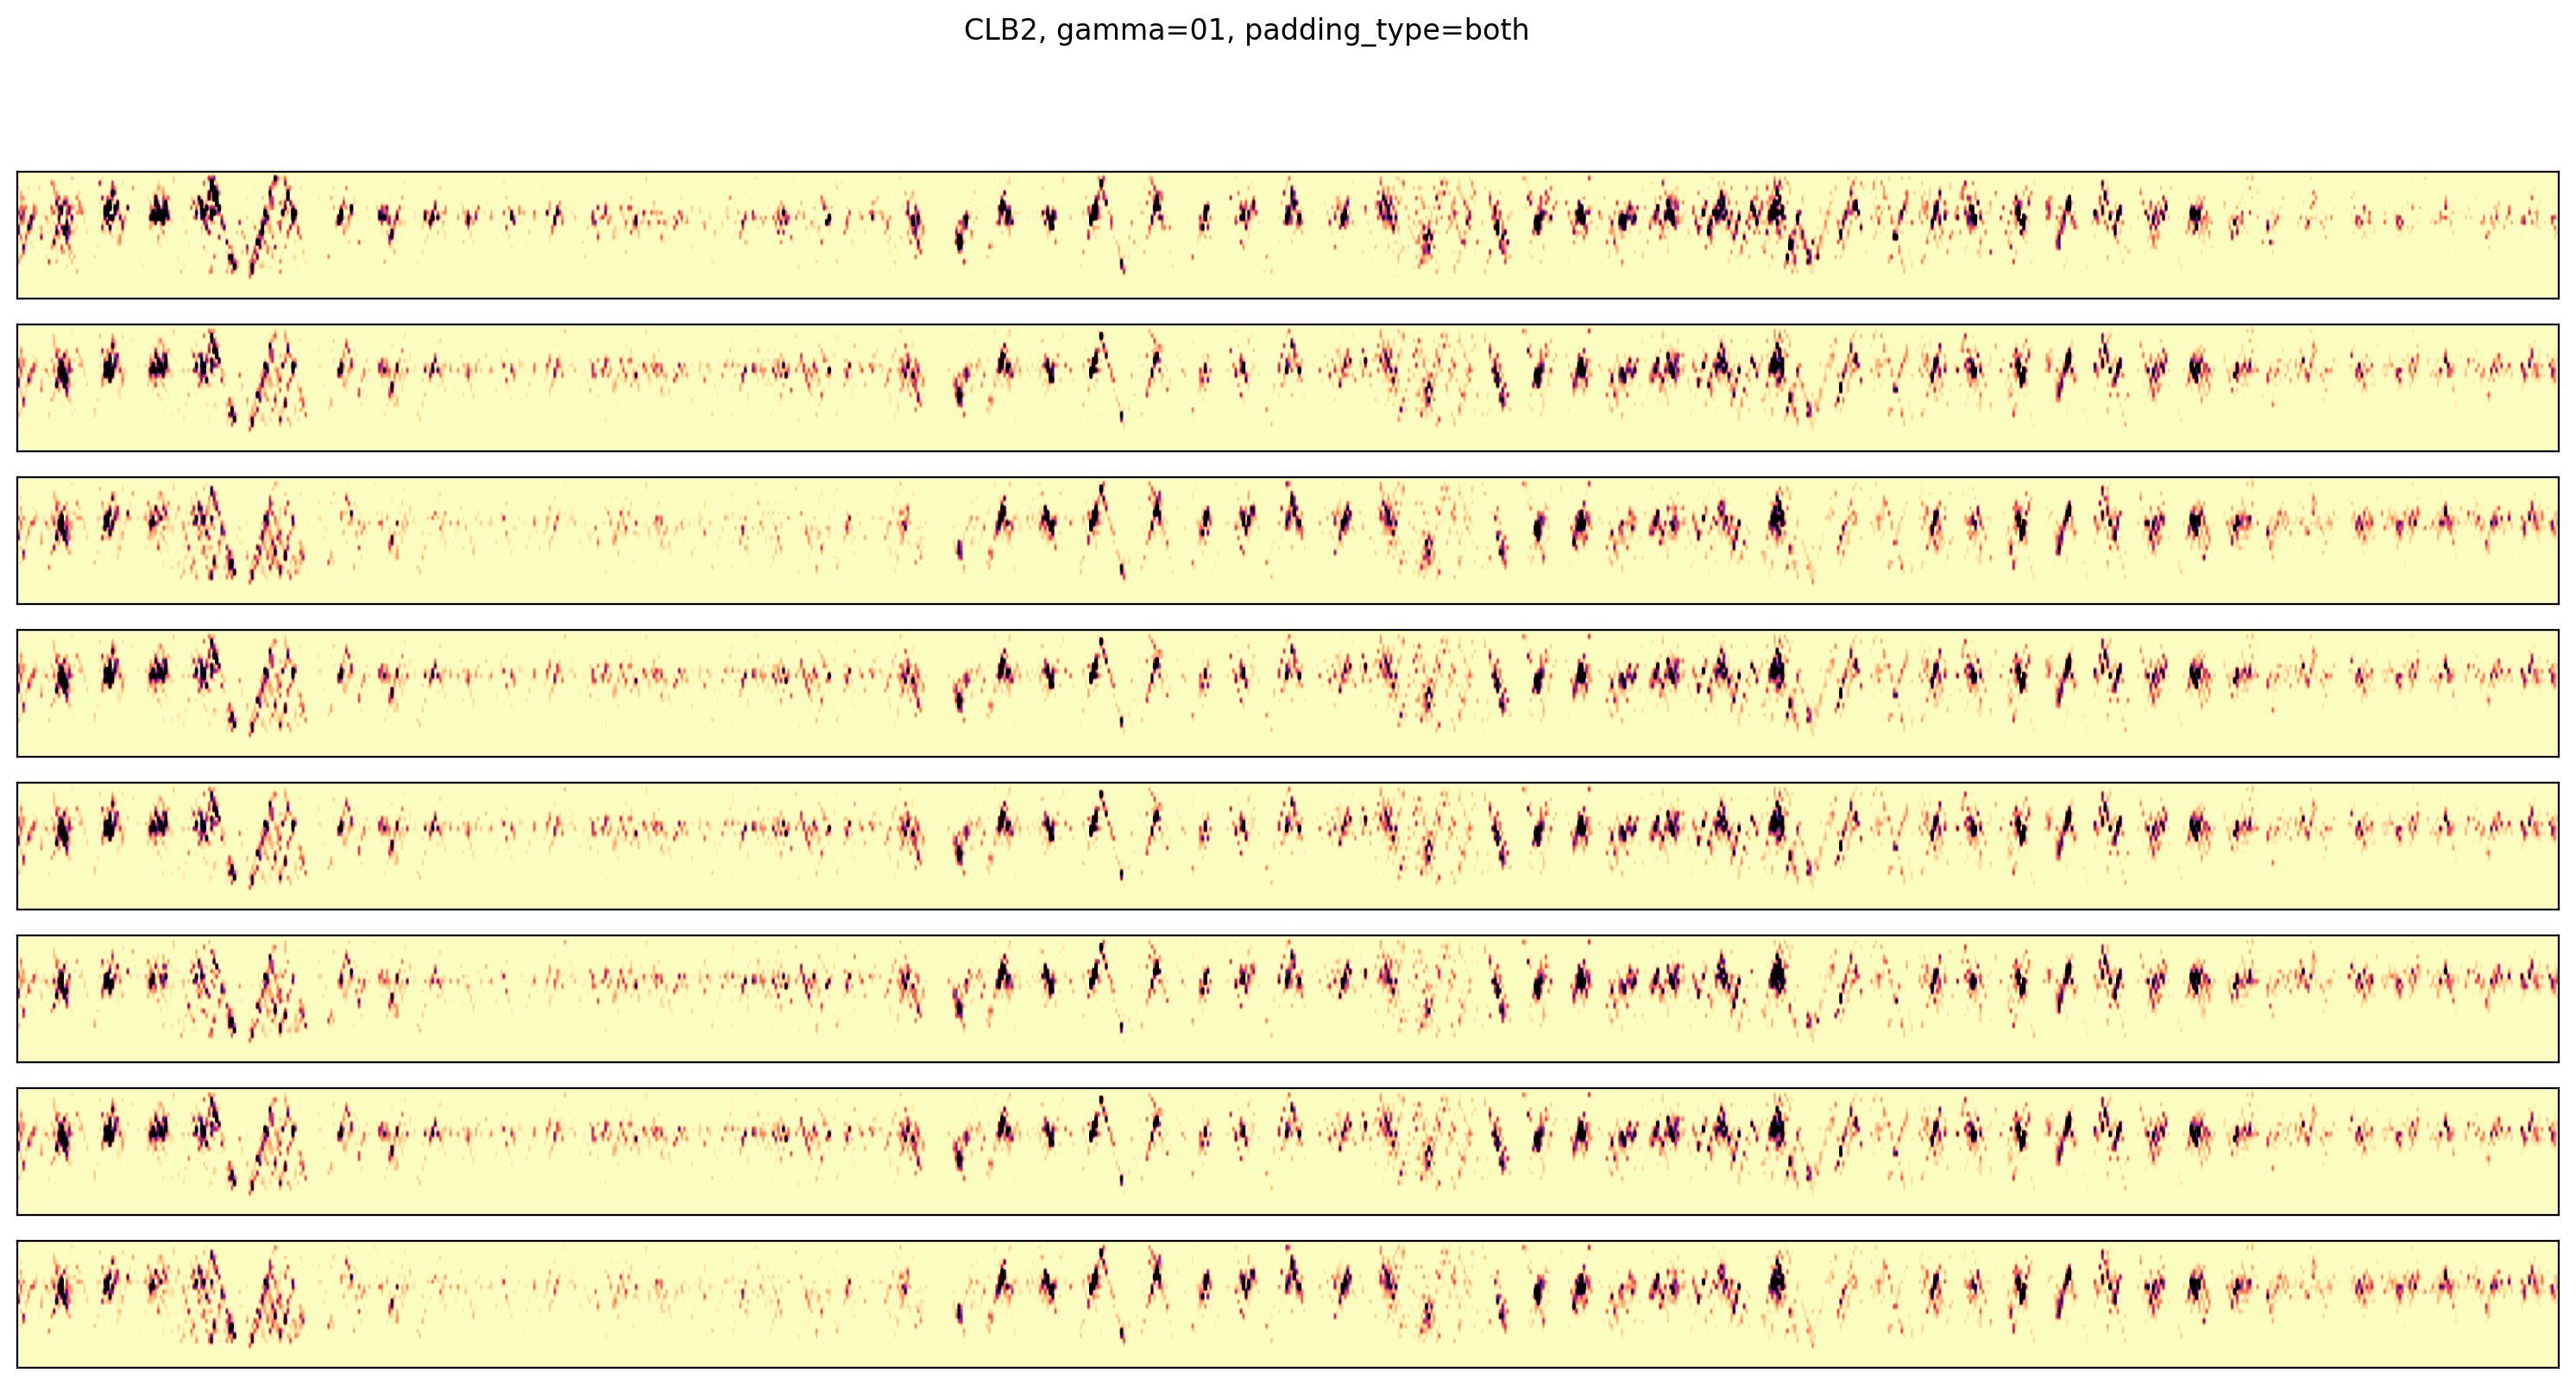

In [1893]:
plot_f_imgs_set('01', 'both')

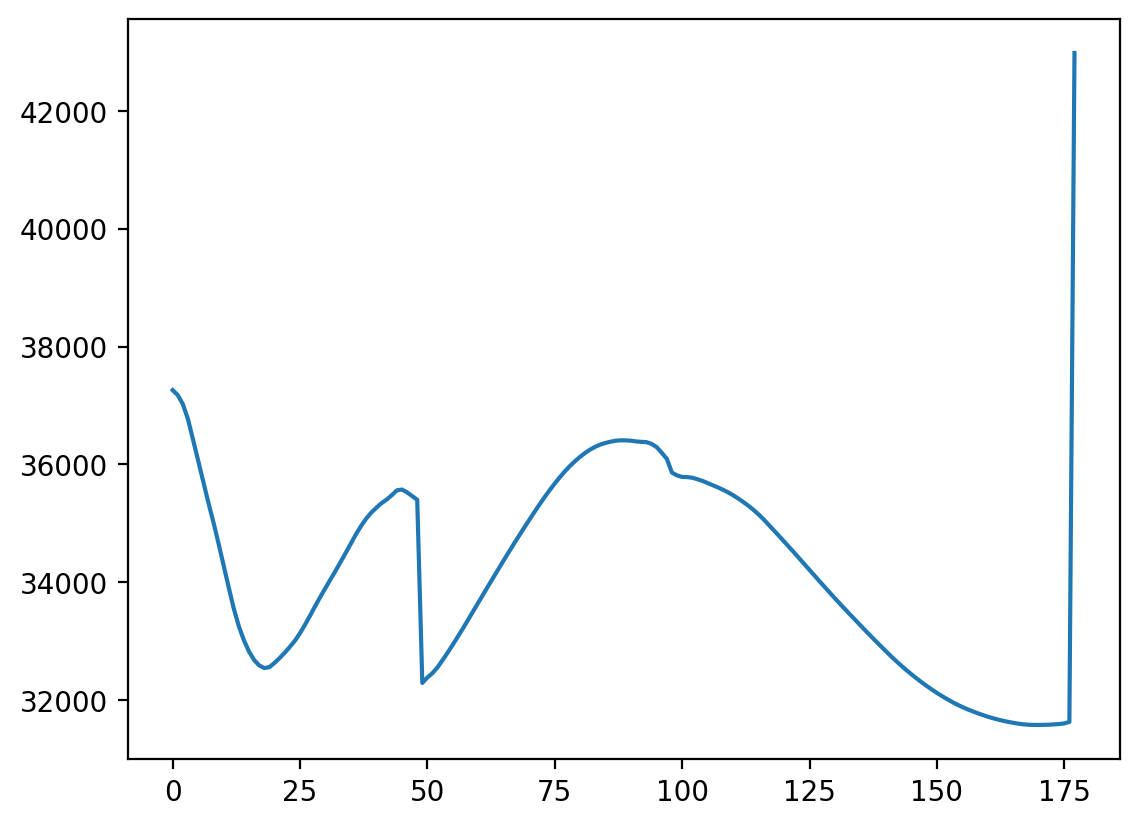

In [1945]:
plt.plot(f_imgs.sum(axis=1).sum(axis=1))

Text(0.5, 0.98, 'Small fragment reads')

<Figure size 1300x300 with 0 Axes>

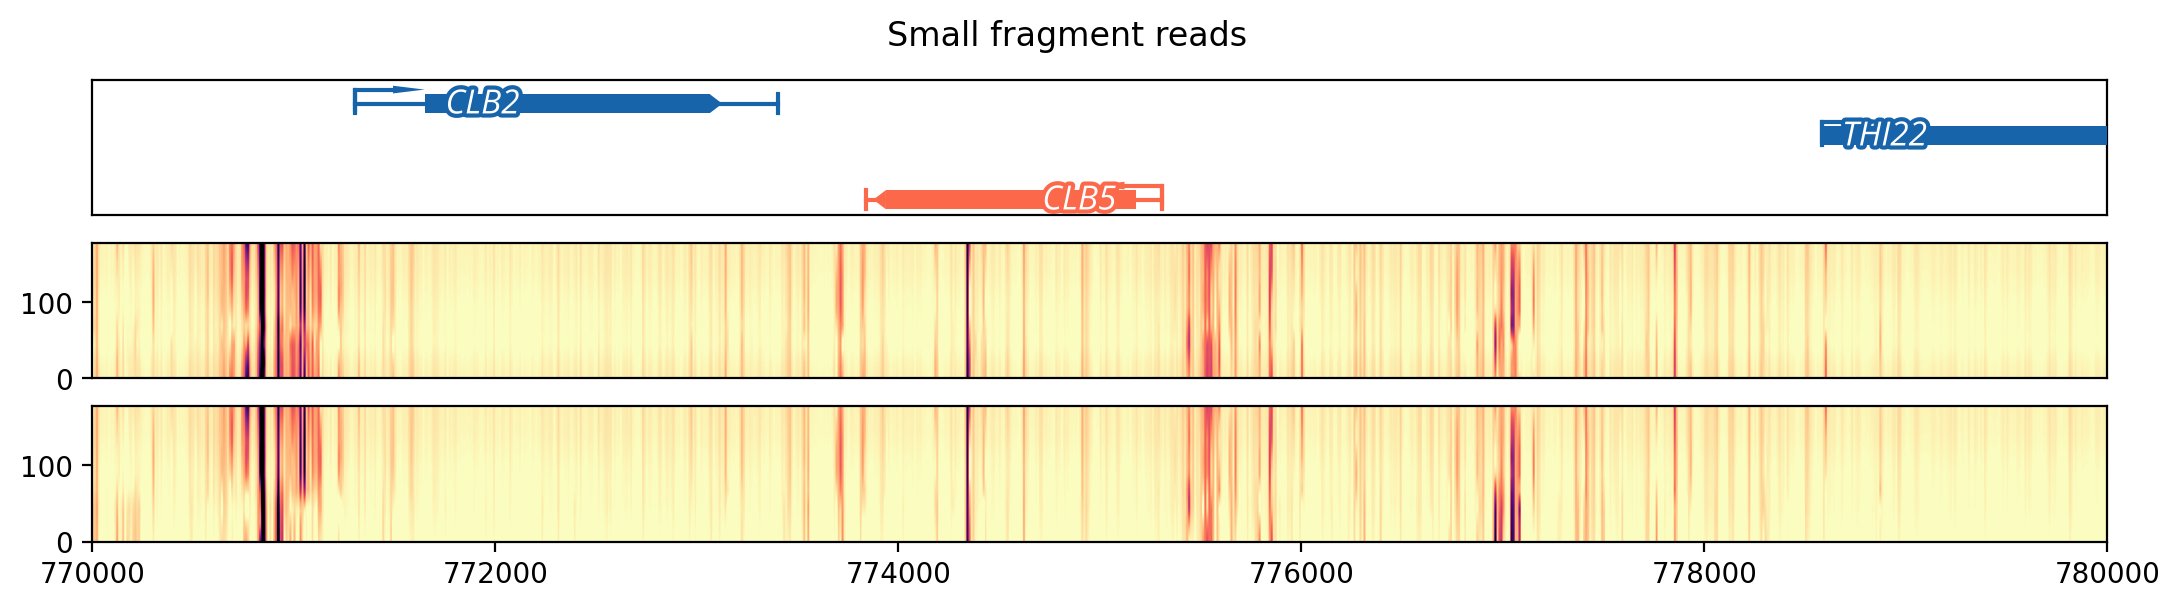

In [2304]:
# Check entropy and small fragments occupancy, is it notable enough to say that 
# it is different enough from the copy number and model bias curves?
gamma = '01'
padding_type = 'both'
clb2_g01_path = (f'output/deconvolved_test_windows_g{gamma}_{padding_type}/data/chr16/chr16_770000_780000.npy')
f_imgs = np.load(clb2_g01_path)

f_imgs_normalized = f_imgs / f_imgs.mean(axis=1).mean(axis=1).reshape((-1, 1, 1))

# Quantification of CLB2 entropy and small fragment changes

sm_indices = 0, 10
nuc_indices = np.arange(120, 170, 10)//10

plt.figure(figsize=(13, 3))

chrom, span = 16, (770000, 780000)
orf_plotter = ORFAnnotationPlotter(genes)
orf_plotter.set_span_chrom(span, chrom)

plt.figure(figsize=(13, 3))
plt.subplot(3, 1, 1)
ax = plt.gca()
orf_plotter.plot_orf_annotations(ax)

plt.subplot(3, 1, 2)
plt.imshow(f_imgs_normalized[t_indices, sm_indices[0]:sm_indices[1], :].mean(axis=1), 
           vmin=0.75, vmax=2, aspect='auto', cmap='magma_r', origin='lower',
           extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]])
plt.xticks([])

plt.subplot(3, 1, 3)
plt.imshow(f_imgs_normalized[i_indices, sm_indices[0]:sm_indices[1], :].mean(axis=1), 
    vmin=0.75, vmax=2, aspect='auto', cmap='magma_r', origin='lower',
           
    extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]])
plt.suptitle("Small fragment reads")

# This matches with the idea that gene expression is lowest in G1,
# The small fragments are fewest here as well (the pattern is different)...
# Worth noting a pattern change here is an interesting marker of gene expression dynamics...


Text(0.5, 0.98, 'Nucleosome reads')

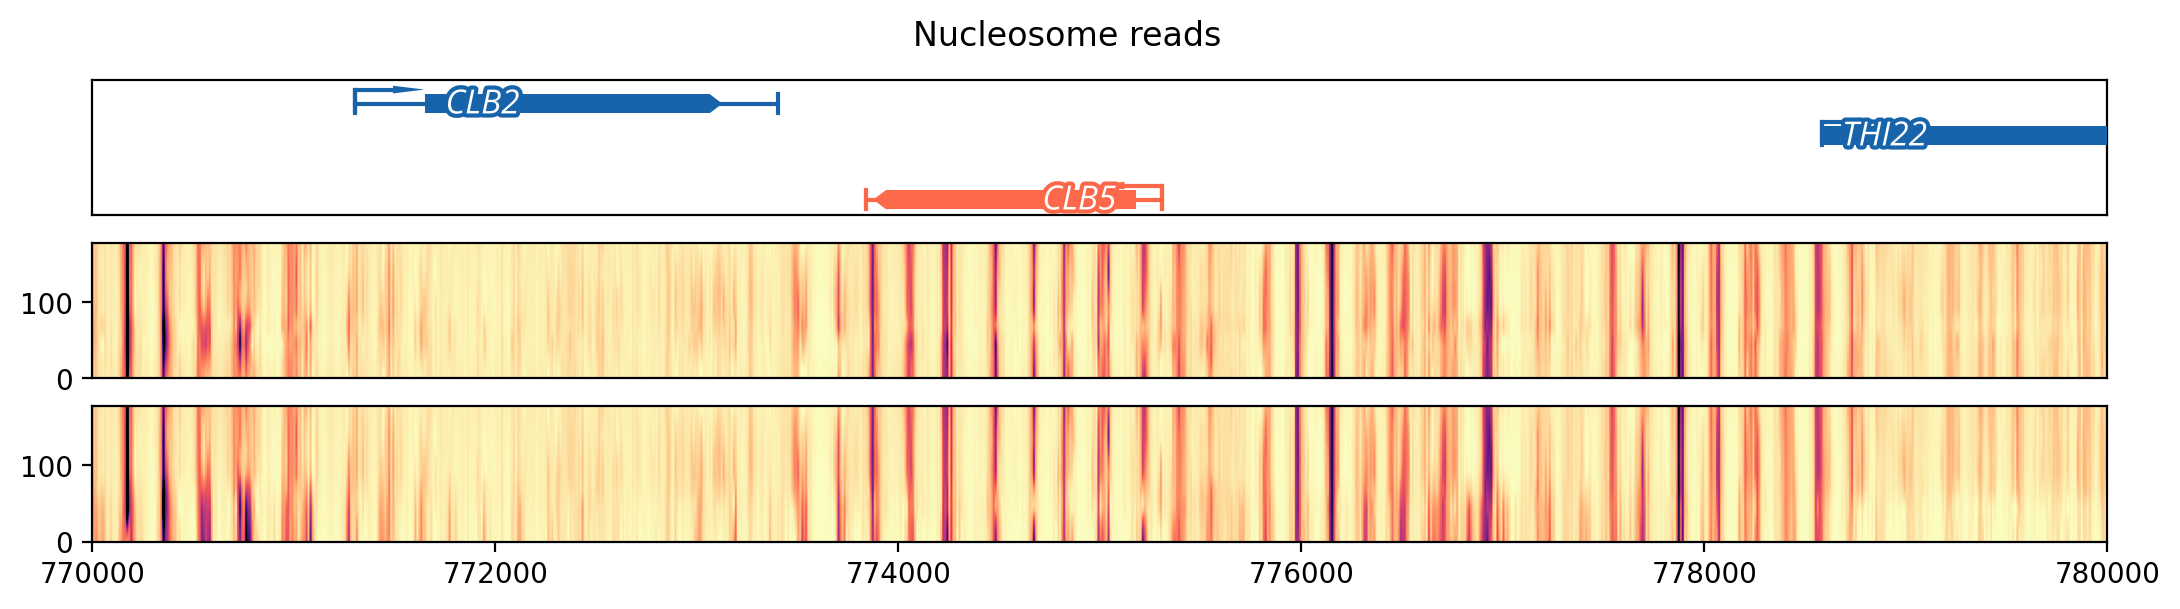

In [2305]:
from src.orf_plotter import ORFAnnotationPlotter
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
nuc_indices = 10, 25

nuc_f_imgs = f_imgs_normalized[:, nuc_indices[0]:nuc_indices[1], :].mean(axis=1)

chrom, span = 16, (770000, 780000)
orf_plotter = ORFAnnotationPlotter(genes)
orf_plotter.set_span_chrom(span, chrom)

plt.figure(figsize=(13, 3))
plt.subplot(3, 1, 1)
ax = plt.gca()
orf_plotter.plot_orf_annotations(ax)

plt.subplot(3, 1, 2)
plt.imshow(nuc_f_imgs[t_indices], vmin=0.75, vmax=5, aspect='auto',
           cmap='magma_r', origin='lower',
          extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]])
plt.xticks([])

plt.subplot(3, 1, 3)
plt.imshow(nuc_f_imgs[i_indices], vmin=0.75, vmax=5, aspect='auto',
           cmap='magma_r', origin='lower',
          extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]])

plt.suptitle("Nucleosome reads")
# Nucleosome occupancy is clearest during G1, there is also a downstream
# nucleosome occupancy movement during G1 compared to the rest of the time course.
# this is associated with CLB2's gene expression being the lowest here...


In [ ]:
# Create a nucleosome kernel to collect the nucleosome reads that can be 
# computed for entropy scoring, use the same logic as the cadmium paper

from scipy.stats import 

In [2307]:
from src.mnase_kernel import MNaseSeqDensityKernel
from src.helpers import downsample_bins

kernel = MNaseSeqDensityKernel()
kernel.compute_kernel()

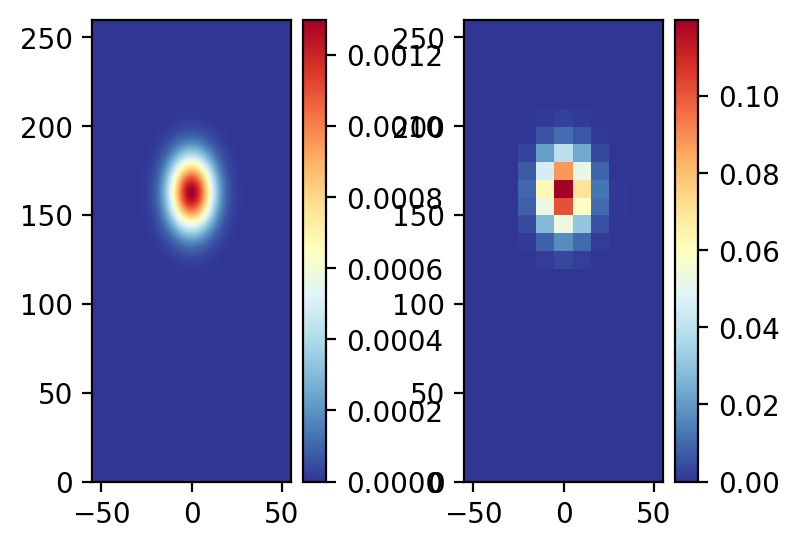

In [2311]:
# Nucleosome kernel
kernel.plot()


In [ ]:
from src.helpers import calc_entropy

def compute_sliding_window_entropy(f_imgs_normalized, window=5, kernel=None):
    """"
    # Compute the entropy of the window 50 indices (500 bp) wide
    """

    arr = f_imgs_normalized
    pad_width = window//2

    shp = arr.shape

    # Pad the ends of the array
    padded_arr = np.concatenate([np.zeros((shp[0], shp[1], pad_width)), 
        arr, np.zeros((shp[0], shp[1], pad_width))],
                               axis=2)

    entropy_values = np.zeros((shp[0], shp[2]))
    occupancy_values = np.zeros((shp[0], shp[2]))

    for i in range(pad_width, arr.shape[2]+pad_width):

        padded_start, padded_end = i-pad_width, i+pad_width+1
        current_segment = padded_arr[:, :,
            padded_start:padded_end]
    
        # Multiply the kernel by the segment to compute the selected
        # reads with smoothing
        segment_kernel_mul = current_segment * kernel.reshape(1, *kernel.shape)

        # Compute entropy for each of the window slices
        flattened_frag_lens_segment = segment_kernel_mul.reshape((shp[0], -1))
        
        nuc_entropies = \
            np.apply_along_axis(lambda row: calc_entropy(row+0.001), axis=1, 
                                arr=flattened_frag_lens_segment)
        
        entropy_values[:, padded_start] = nuc_entropies
        occupancy_values[:, padded_start] = segment_kernel_mul.sum(axis=1).sum(axis=1)

    return entropy_values, occupancy_values

entropy_values, occupancy_values = compute_sliding_window_entropy(f_imgs_normalized[:, :, :], window=11,
    kernel=kernel.kernel_mat_down_sampled)


Text(0.5, 0.98, 'Smoothed nucleosome entropy')

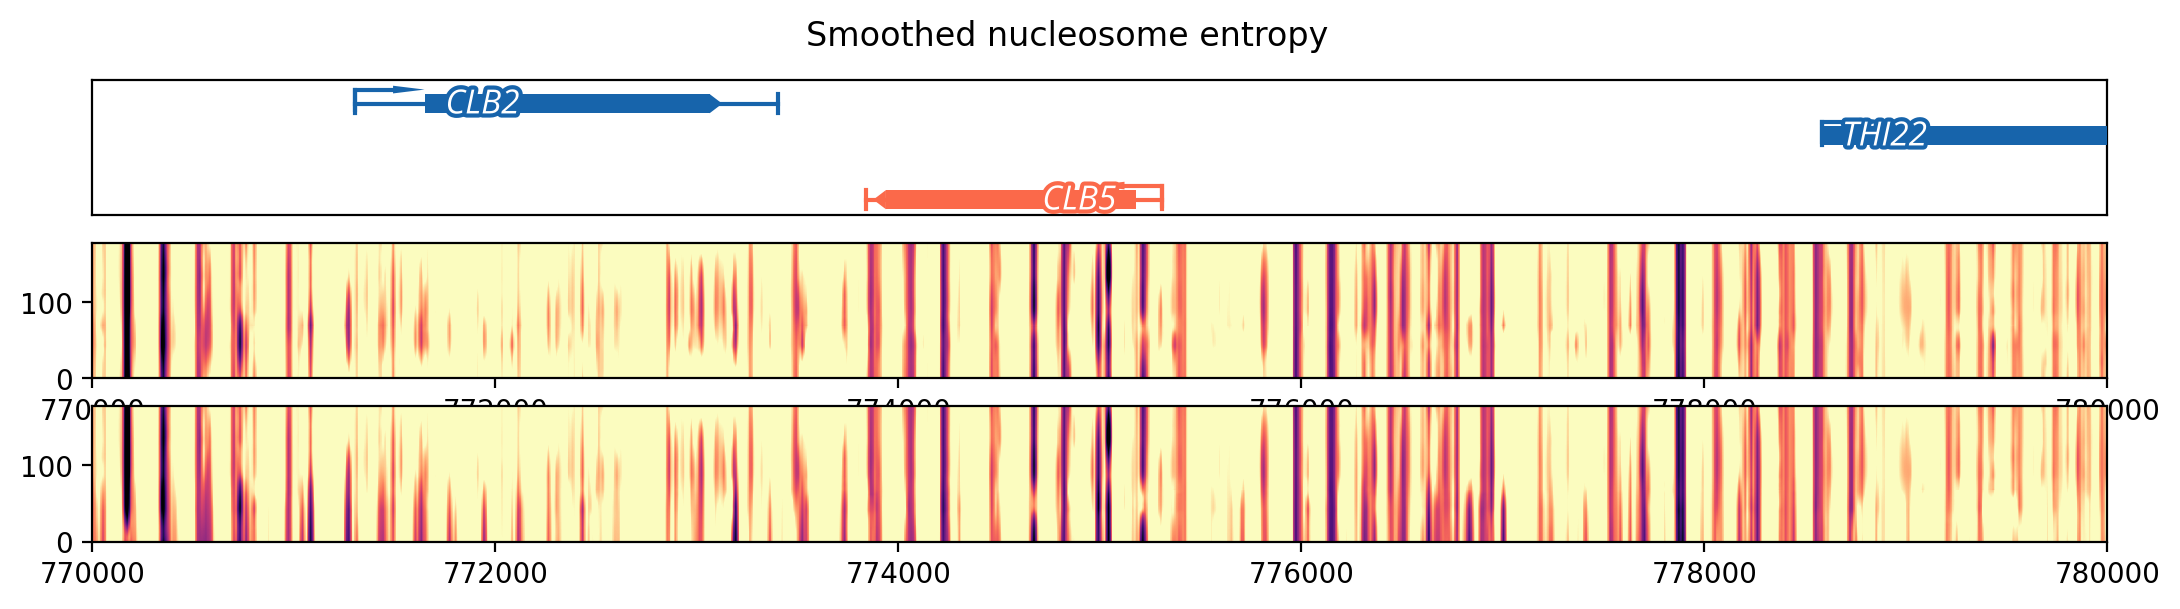

In [2318]:
plt.figure(figsize=(13, 3))
plt.subplot(3, 1, 1)
ax = plt.gca()
orf_plotter.plot_orf_annotations(ax)

plt.subplot(3, 1, 2)
plt.imshow(-entropy_values[t_indices], origin='lower', cmap='magma_r', aspect='auto',
          vmin=-5.5, vmax=-3, extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]]
          )

plt.subplot(3, 1, 3)
plt.imshow(-entropy_values[i_indices], origin='lower', cmap='magma_r', aspect='auto',
          vmin=-5.5, vmax=-3, extent=[span[0], span[1], 0, f_imgs_normalized.shape[0]]
          )

plt.suptitle("Smoothed nucleosome entropy")

Text(0.5, 1.0, '10kb occupancy curve, gamma=0.0066')

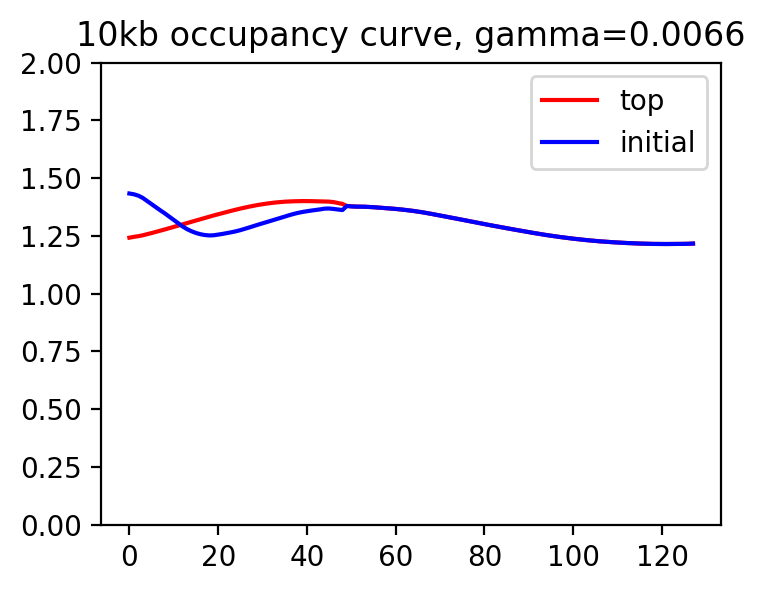

In [2002]:
clb2_g0066_path = (f'output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/data/chr16/chr16_770000_780000.npy')

plt.figure(figsize=(4, 3))
plot(clb2_g0066_path)
plt.ylim(0, 2)
plt.title("10kb occupancy curve, gamma=0.0066")

Text(0.5, 1.0, '10kb occupancy curve, gamma=0.4')

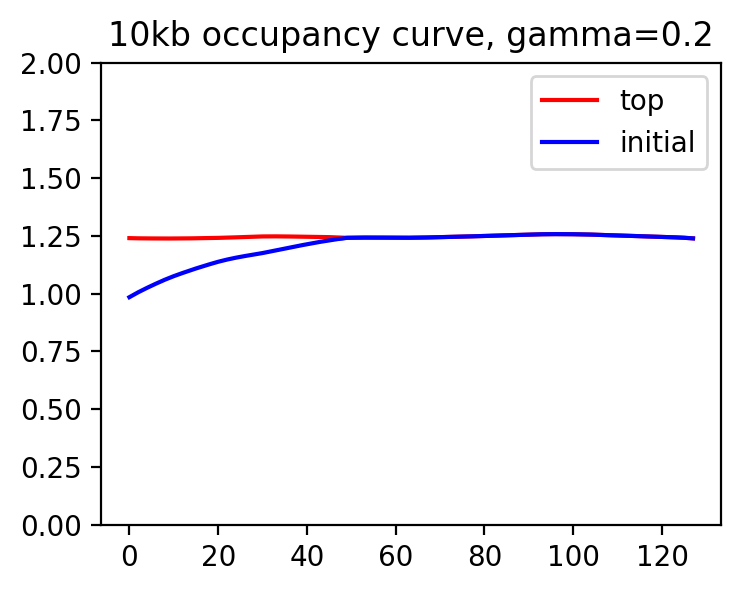

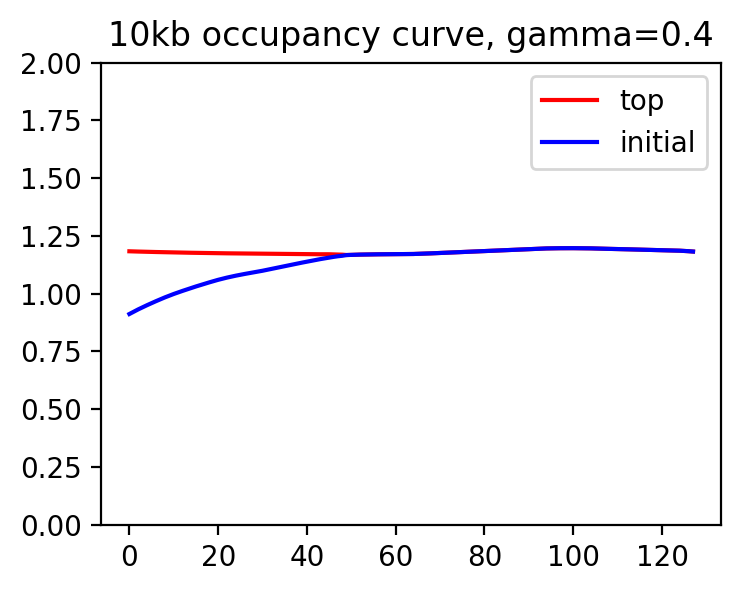

In [2004]:
clb2_g02_path = (f'output/deconvolved_test_windows_g02_{padding_type}/data/chr16/chr16_770000_780000.npy')
clb2_g04_path = (f'output/deconvolved_test_windows_g04_{padding_type}/data/chr16/chr16_770000_780000.npy')

plt.figure(figsize=(4, 3))
plot(clb2_g02_path)
plt.ylim(0, 2)
plt.title("10kb occupancy curve, gamma=0.2")

plt.figure(figsize=(4, 3))
plot(clb2_g04_path)
plt.ylim(0, 2)
plt.title("10kb occupancy curve, gamma=0.4")

Text(0.5, 1.0, '10kb occupancy curve, gamma=0.1')

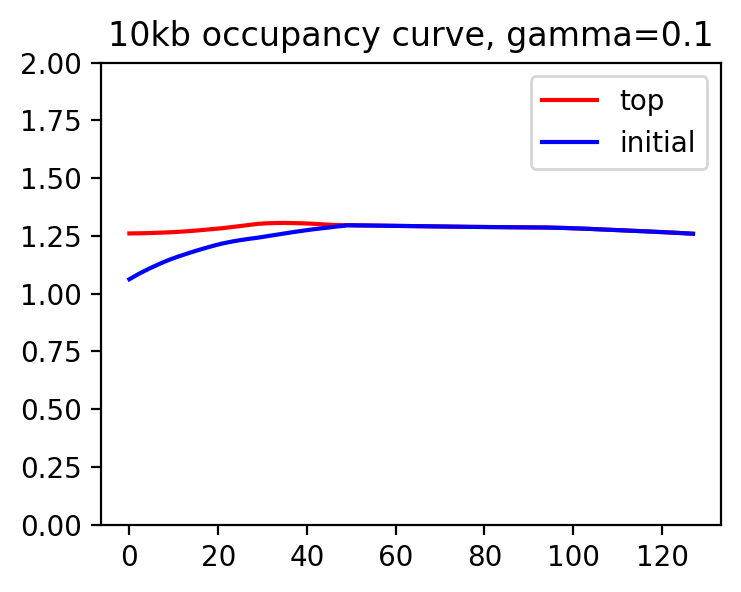

In [2003]:
plt.figure(figsize=(4, 3))
plot(clb2_g01_path)
plt.ylim(0, 2)
plt.title("10kb occupancy curve, gamma=0.1")